In [87]:
def compute_groupwise_stim_distance(centroidX, centroidY, photostim, stim_type = 'photostim_post'):
    """
    Compute stimDist: distance from each neuron to each unique stimulation group.
    
    Parameters:
    centroidX, centroidY : arrays of neuron coordinates
    photostim : pandas.DataFrame containing photostim trials
    stim_type : str, 'photostim' or 'photostim_post'
    
    Returns:
    --------
    stimDist_group : array of shape (n_neurons, n_groups)
    """
    roi_coords = np.stack((centroidX, centroidY), axis=1)  # shape (n_neurons, 2)

    # Group photostim trials by group_index and compute group centroid
    group_table = photostim[photostim.stim_name == stim_type]
    groups = group_table.groupby('group_index')[['laser_stim_x', 'laser_stim_y']].mean()
    stim_coords = groups.values  # shape (n_groups, 2)

    n_rois = roi_coords.shape[0]
    n_groups = stim_coords.shape[0]

    stimDist_group = np.zeros((n_rois, n_groups))
    for g in range(n_groups):
        dx = roi_coords[:, 0] - stim_coords[g, 0]
        dy = roi_coords[:, 1] - stim_coords[g, 1]
        stimDist_group[:, g] = np.sqrt(dx**2 + dy**2)

    return stimDist_group

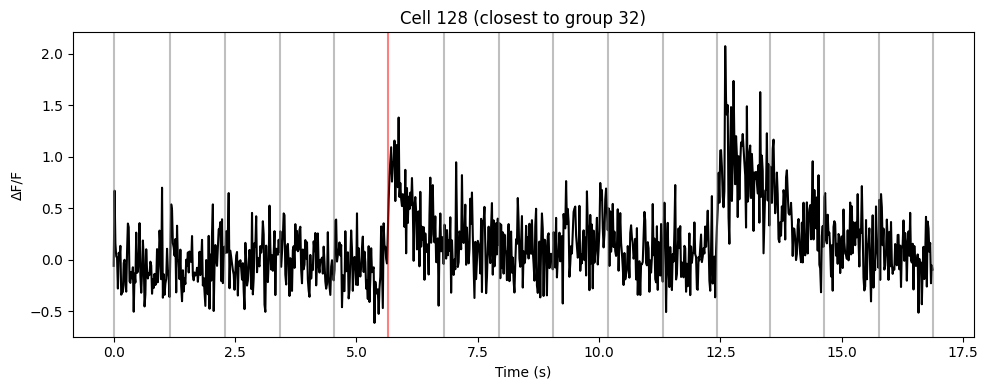

In [103]:
trial_of_interest = 5
# Compute ROI coordinates
centroids = get_roi_centroids(image_segmentation)  # returns (n_rois, 2)
centroidX = centroids[:, 0]
centroidY = centroids[:, 1]
roi_coords = np.stack((centroidX, centroidY), axis=1)  # (n_neurons, 2)

# Get early events
events = photostim[photostim.stim_name == 'photostim'].iloc[:16]
stim_frames = events['start_frame'].values
groups = events['group_index'].values

# Compute group coordinates (mean x/y per group)
group_means = photostim[photostim.stim_name == 'photostim'] \
    .groupby('group_index')[['laser_stim_x', 'laser_stim_y']].mean()

# Align group order to those used in this block
stim_coords = group_means.loc[groups].values  # shape: (n_groups, 2)

# Compute stimDist manually
stimDist = np.linalg.norm(roi_coords[:, None, :] - stim_coords[None, :, :], axis=2)  # (n_rois, n_groups)

# Trial of interest
group = groups[trial_of_interest] - 1  # MATLAB to Python indexing
cell = np.argmin(stimDist[:, trial_of_interest])  # closest to that group's stim coords
# need to adjust the indexing here as stimDist is numerical order of cells, not in the grouped order 

# Time window
start_f = max(0, stim_frames[0] - int(0.2 * frame_rate))
stop_f  = min(len(dff), stim_frames[-1] + int(0 * frame_rate))
t = np.arange(start_f, stop_f) / frame_rate

# Plot
trace = dff[start_f:stop_f, cell]
plt.plot(t, trace, 'k')

for i, f in enumerate(stim_frames):
    if start_f <= f <= stop_f:
        color = 'gray'
        if i == trial_of_interest:
            color = 'r'
        plt.axvline(f / frame_rate, color=color, alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('ΔF/F')
plt.title(f'Cell {cell} (closest to group {group})')
plt.tight_layout()
plt.show()

In [89]:
stimDist_group = compute_groupwise_stim_distance(centroidX, centroidY, photostim)
np.shape(stimDist_group)

(385, 50)

In [90]:
cell

np.int64(128)

In [91]:
cell_group = np.argmin(stimDist_group[:, trial_of_interest])  # closest to that group's stim coords
cell_group

np.int64(331)

In [101]:
np.shape(stimDist_group)
# nrois, ntrials 
# this is ordered by the roi order....  

# what is a hardcoded order I can use? the group index number 

(385, 50)

In [100]:
np.shape(stimDist)

(385, 16)

In [102]:
np.shape(roi_coords)

(385, 2)

In [ ]:
# why aren't the trials in the same order? 